In [2]:
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
from rebar_object_detection import get_bounding_boxes, get_lines
import json

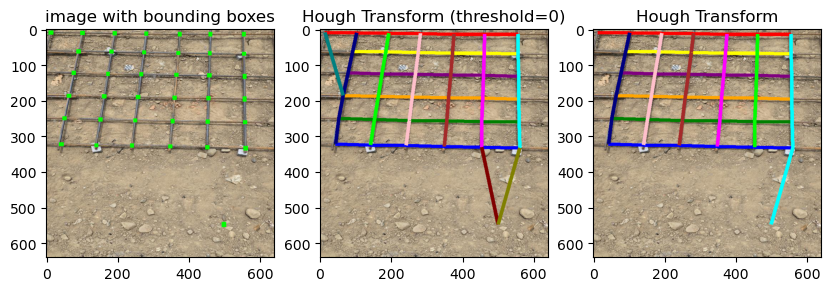

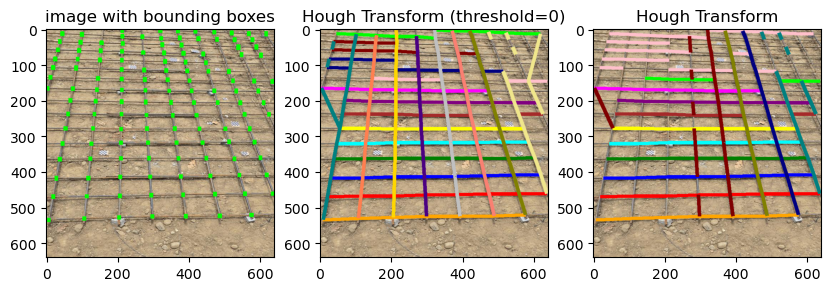

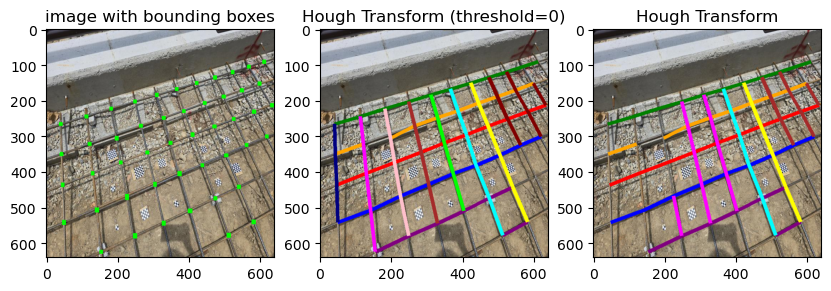

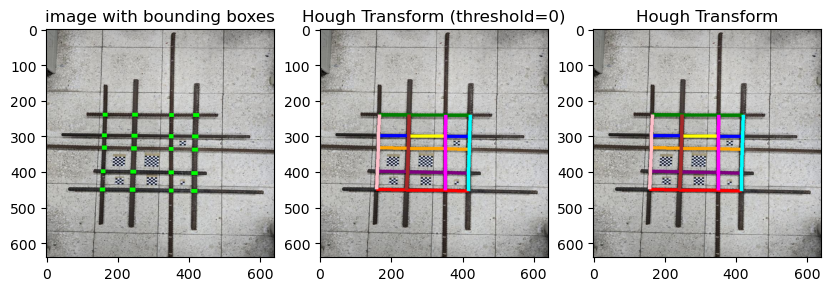

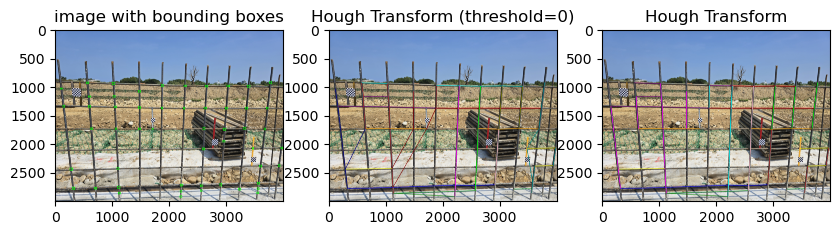

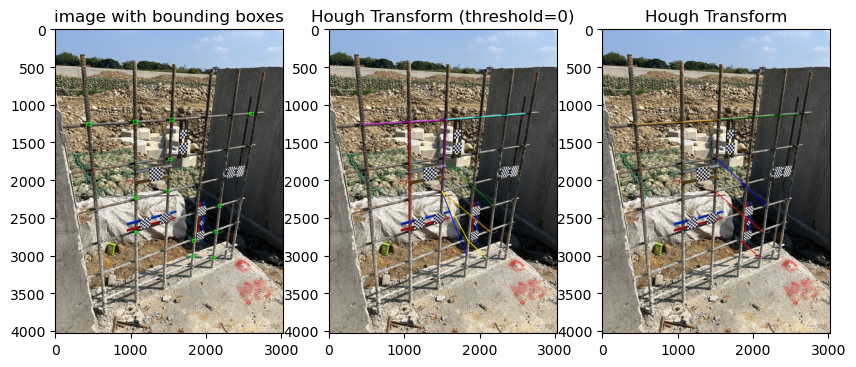

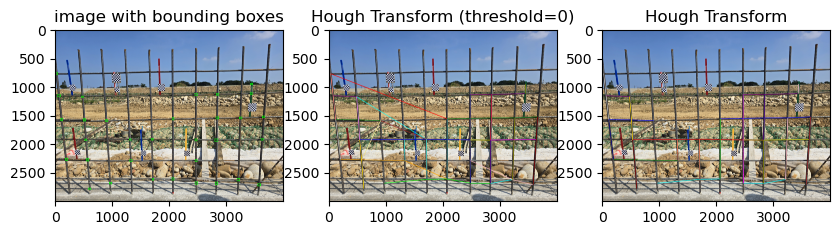

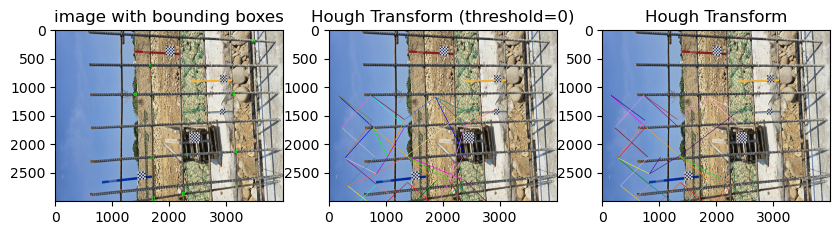

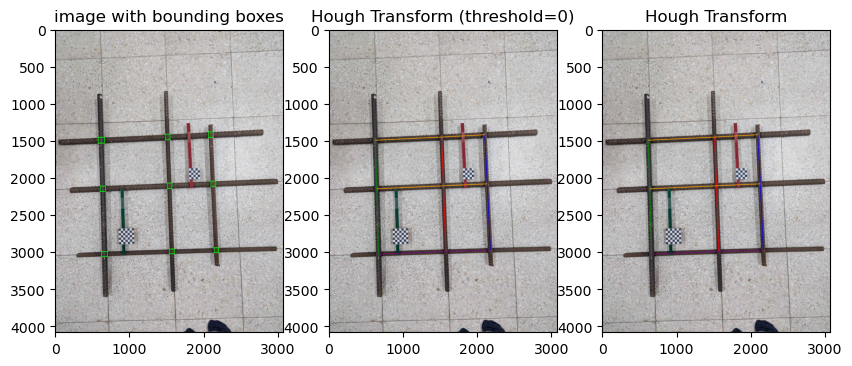

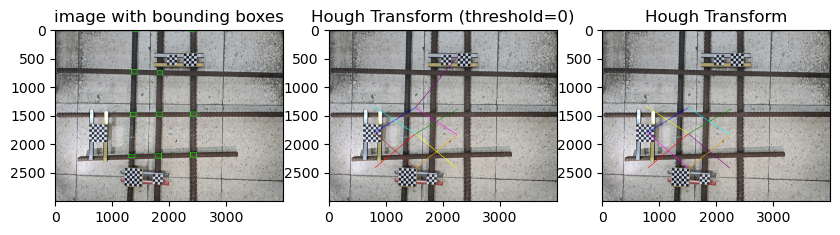

In [14]:
image_paths = [
    "data/intersect-detect/test/images/20250620_115012_jpg.rf.239a32ab7bcbefe30fb9f388607d7048.jpg",
    "data/intersect-detect/test/images/20250620_114830_jpg.rf.5e2332d4c667c38b39dfc6d6839eddf1.jpg",
    "data/intersect-detect/test/images/20250620_113200_jpg.rf.c129e547c74634bf1848bf9ef225a321.jpg",
    "data/intersect-detect/test/images/20250613_203702_jpg.rf.8a0542000d31483bd3869d89a7ec7bc0.jpg",
    "/Users/earnesthsiao/Downloads/20250914_104359.jpg",
    "/Users/earnesthsiao/Downloads/IMG_7568.jpg",
    "/Users/earnesthsiao/Downloads/20250914_093354.jpg",
    "/Users/earnesthsiao/Downloads/20250914_110048.jpg",
    "/Users/earnesthsiao/Downloads/20250918_1m_00000.jpg",
    "/Users/earnesthsiao/Downloads/20250815_135227.jpg",
]
model_path = "runs/detect/tune/weights/best.pt"


# Draw bounding boxes
def draw_bounding_boxes(image_path, model_path):
    image = Image.open(image_path)
    draw_boxes = ImageDraw.Draw(image)

    bounding_boxes = get_bounding_boxes(image, model_path)
    for box in bounding_boxes:
        draw_boxes.rectangle([box[0], box[1], box[2], box[3]], outline="lime", width=10)

    return image


# Define different colors for different groups
colors = [
    "red", "blue", "green", "orange", "purple", "yellow", "cyan", "magenta", 
    "brown", "pink", "lime", "navy", "maroon", "olive", "teal", "silver",
    "gold", "indigo", "coral", "salmon", "khaki", "violet", "crimson", 
    "turquoise", "plum", "chocolate", "tomato", "orchid", "steelblue", 
    "darkgreen", "firebrick", "mediumblue", "darkorange", "darkviolet",
    "forestgreen", "hotpink", "royalblue", "darkred", "limegreen", "deeppink"
]

# Draw lines
def draw_lines(image_path, model_path, threshold=10):
    image = Image.open(image_path).copy()
    draw_lines = ImageDraw.Draw(image)

    json_data = get_lines(image_path, model_path, threshold=threshold)
    data = json.loads(json_data)
    
    # Use different colors for different groups, cycling through the color list
    for i, shape in enumerate(data["shapes"]):
        lines = shape["lines"]
        color = colors[i % len(colors)]
        
        # Draw each line in the group
        for line in lines:
            draw_lines.line([tuple(line[0]), tuple(line[1])], fill=color, width=10)

    return image


def show_result(image_path, model_path):
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 3, 1)
    plt.title("image with bounding boxes")
    plt.imshow(draw_bounding_boxes(image_path, model_path))
    plt.subplot(1, 3, 2)
    plt.title("Hough Transform (threshold=0)")
    # Still applying line pruning
    plt.imshow(draw_lines(image_path, model_path, threshold=0))
    plt.subplot(1, 3, 3)
    plt.title("Hough Transform")
    plt.imshow(draw_lines(image_path, model_path))
    plt.show()


for path in image_paths:
    show_result(path, model_path)
